# KAAPAV Phase Classification — German BERT fine-tune + zero-shot

**VALOR NLP layer · Group Assignment Option 1 (Application Development)**

This notebook trains the *core* model of the KAAPAV phase-labelling layer: a fine-tuned
German BERT 6-class classifier, then compares it against a zero-shot baseline.
It reuses the pattern from the course repo
`06_transfer_learning_and_fine_tuning/practice_solution.ipynb`
(`AutoModelForSequenceClassification` + `Trainer` + `classification_report`),
adapted from 2-class disaster tweets to the 6-class ordered KAAPAV taxonomy.

**Runtime:** set *Runtime → Change runtime type → GPU*.

Pipeline stages (matching the project README):
1. Lexicon + rules  · 2. TF-IDF + LogReg  · **3. German BERT (this notebook)**  ·
4. Viterbi smoothing · 5. Zero-shot / LLM (this notebook)


## 0. Setup


In [1]:
!pip install -q transformers datasets evaluate accelerate scikit-learn seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.5 MB/s eta 0:00:00


In [2]:
# Get the project code + data into Colab.
# Option A (recommended): clone your team's repo, then point ROOT at it.
# Option B: upload data/synthetic_transcripts.jsonl + data/gold_eval.jsonl manually.
import os, pathlib
ROOT = pathlib.Path('valor-nlp-layer')  # <-- adjust to your repo path in Colab
if not (ROOT/'data'/'gold_eval.jsonl').exists():
    from google.colab import files
    print('Upload synthetic_transcripts.jsonl and gold_eval.jsonl:')
    up = files.upload()
    ROOT = pathlib.Path('.'); (ROOT/'data').mkdir(exist_ok=True)
    for fn in up:
        os.replace(fn, ROOT/'data'/fn)
print('data dir:', (ROOT/'data').resolve())


Upload synthetic_transcripts.jsonl and gold_eval.jsonl:


Saving gold_eval.jsonl to gold_eval.jsonl
Saving synthetic_transcripts.jsonl to synthetic_transcripts.jsonl
data dir: /content/data


## 1. Load the labelled segments
Calls are pre-split by `call_id` (no call leaks across train/eval).


In [3]:
import json, numpy as np, pandas as pd
def load_jsonl(p):
    return [json.loads(l) for l in open(p, encoding='utf-8') if l.strip()]
train = load_jsonl(ROOT/'data'/'synthetic_transcripts.jsonl')
ev    = load_jsonl(ROOT/'data'/'gold_eval.jsonl')
PHASES = ['Kontakt','Analyse','Angebot','Pruefung','Abschluss','Verstaerkung']
lab2id = {p:i for i,p in enumerate(PHASES)}; id2lab = {i:p for p,i in lab2id.items()}
print(len(train),'train segments |',len(ev),'eval segments')
pd.Series([s['phase'] for s in train]).value_counts()


1231 train segments | 448 eval segments


,count
Angebot,275
Pruefung,269
Analyse,244
Abschluss,169
Kontakt,164
Verstaerkung,110


## 2. Build HuggingFace datasets
We carry `rel_position` into the text as a light prefix token bucket so the
transformer also sees *where* in the call the segment sits — position is the
single most discriminative feature per the KAAPAV reference (Sec. 3).


In [4]:
from datasets import Dataset, DatasetDict

def add_pos(segs):
    by={}
    for s in segs: by.setdefault(s['call_id'],[]).append(s)
    for cs in by.values():
        cs.sort(key=lambda s:s['turn']); n=len(cs)
        for i,s in enumerate(cs): s['rel_position']= i/(n-1) if n>1 else 0.0
    return segs
train=add_pos(train); ev=add_pos(ev)

def to_df(segs):
    rows=[]
    for s in segs:
        bucket=['START','EARLY','MID','LATE','END'][min(4,int(s['rel_position']*5))]
        rows.append({'text': f"[{s['speaker'].upper()}|{bucket}] {s['text']}",
                     'label': lab2id[s['phase']], 'call_id': s['call_id'],
                     'turn': s['turn'], 'phase': s['phase']})
    return pd.DataFrame(rows)
train_df, eval_df = to_df(train), to_df(ev)

from sklearn.model_selection import GroupShuffleSplit
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
tr_idx, val_idx = next(gss.split(train_df, groups=train_df['call_id']))
ds = DatasetDict({
    'train': Dataset.from_pandas(train_df.iloc[tr_idx].reset_index(drop=True)),
    'validation': Dataset.from_pandas(train_df.iloc[val_idx].reset_index(drop=True)),
    'test': Dataset.from_pandas(eval_df)})
ds

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'call_id', 'turn', 'phase'],
        num_rows: 1036
    })
    validation: Dataset({
        features: ['text', 'label', 'call_id', 'turn', 'phase'],
        num_rows: 195
    })
    test: Dataset({
        features: ['text', 'label', 'call_id', 'turn', 'phase'],
        num_rows: 448
    })
})

## 3. Tokenize
`bert-base-german-cased` is the German BERT checkpoint used here.


In [5]:
from transformers import AutoTokenizer, DataCollatorWithPadding
checkpoint='bert-base-german-cased'
tok=AutoTokenizer.from_pretrained(checkpoint)
collator=DataCollatorWithPadding(tokenizer=tok)
def prep(b): return tok(b['text'], truncation=True)
tds=ds.map(prep, batched=True)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/433 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/255k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/485k [00:00<?, ?B/s]

Map:   0%|          | 0/1036 [00:00<?, ? examples/s]

Map:   0%|          | 0/195 [00:00<?, ? examples/s]

Map:   0%|          | 0/448 [00:00<?, ? examples/s]

## 4. Fine-tune (Trainer) — course pattern, 6 labels


In [6]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer, set_seed
import evaluate
set_seed(42)
acc=evaluate.load('accuracy'); f1=evaluate.load('f1')
def compute_metrics(p):
    logits,labels=p; pred=np.argmax(logits,axis=-1)
    return {'accuracy':acc.compute(predictions=pred,references=labels)['accuracy'],
            'macro_f1':f1.compute(predictions=pred,references=labels,average='macro')['f1']}
model=AutoModelForSequenceClassification.from_pretrained(
    checkpoint, num_labels=len(PHASES), id2label=id2lab, label2id=lab2id)
args=TrainingArguments(output_dir='./kaapav_gbert', learning_rate=2e-5,
    per_device_train_batch_size=16, per_device_eval_batch_size=32,
    num_train_epochs=4, weight_decay=0.01, eval_strategy='epoch',
    save_strategy='epoch', load_best_model_at_end=True,
    metric_for_best_model='macro_f1', logging_steps=25, seed=42)
trainer=Trainer(model=model, args=args, train_dataset=tds['train'],
    eval_dataset=tds['validation'], data_collator=collator,
    compute_metrics=compute_metrics)
trainer.train()


model.safetensors:   0%|          | 0.00/439M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-german-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.637155,0.082429,1.000000,1.000000
2,0.014725,0.007155,1.000000,1.000000
3,0.007862,0.004490,1.000000,1.000000
4,0.005900,0.003949,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=260, training_loss=0.22150623593479396, metrics={'train_runtime': 61.9213, 'train_samples_per_second': 66.924, 'train_steps_per_second': 4.199, 'total_flos': 69025964310576.0, 'train_loss': 0.22150623593479396, 'epoch': 4.0})

## 5. Evaluate on the held-out gold calls (segment-level)


              precision    recall  f1-score   support

     Kontakt       0.84      0.75      0.79        56
     Analyse       0.72      0.80      0.76        94
     Angebot       0.76      0.70      0.73       101
    Pruefung       0.62      0.75      0.68       101
   Abschluss       0.96      0.42      0.59        59
Verstaerkung       0.69      0.97      0.81        37

    accuracy                           0.73       448
   macro avg       0.77      0.73      0.73       448
weighted avg       0.75      0.73      0.72       448



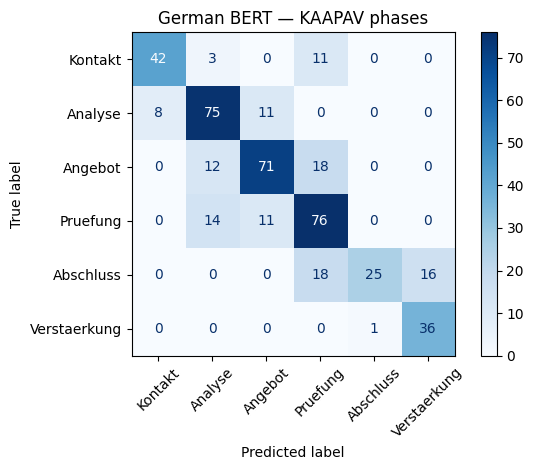

In [7]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
pred_out=trainer.predict(tds['test'])
logits=pred_out.predictions
y_true=pred_out.label_ids
y_pred=np.argmax(logits,axis=-1)
print(classification_report(y_true,y_pred,target_names=PHASES,zero_division=0))
cm=confusion_matrix(y_true,y_pred)
ConfusionMatrixDisplay(cm,display_labels=PHASES).plot(cmap='Blues',xticks_rotation=45)
plt.title('German BERT — KAAPAV phases'); plt.tight_layout(); plt.show()


## 6. Add Viterbi order-smoothing on top of BERT
Per-segment softmax probabilities → Viterbi decode over the canonical
K→A→A→P→A→V transition prior (same smoother as the CPU pipeline, inlined
here so the notebook is self-contained). This recovers the order prior a
per-segment classifier ignores.


In [9]:
import scipy.special as sp
N=len(PHASES); IDX={p:i for i,p in enumerate(PHASES)}

# Estimate the transition + start priors from the TRAINING calls (Laplace-smoothed),
# instead of hand-tuning them. Uses train_df only -> no leakage from the gold set.
def learn_priors(df, alpha=1.0):
    T=np.full((N,N), alpha); st=np.full(N, alpha)
    for _,grp in df.groupby('call_id'):
        seq=[IDX[p] for p in grp.sort_values('turn')['phase']]
        st[seq[0]] += 1
        for a,b in zip(seq, seq[1:]): T[a,b] += 1
    T/=T.sum(1,keepdims=True); st/=st.sum()
    return np.log(T), np.log(st)
T_LOG, ST_LOG = learn_priors(train_df)

def viterbi(em):
    n=em.shape[0]
    dp=np.full((n,N),-np.inf); bk=np.zeros((n,N),int); dp[0]=ST_LOG+em[0]
    for t in range(1,n):
        sc=dp[t-1][:,None]+T_LOG; bk[t]=sc.argmax(0); dp[t]=sc.max(0)+em[t]
    path=[int(dp[-1].argmax())]
    for t in range(n-1,0,-1): path.append(int(bk[t,path[-1]]))
    return [p for p in reversed(path)]

# group eval logits by call (test rows are in eval_df order)
probs = sp.softmax(logits, axis=1)
eval_df = eval_df.reset_index(drop=True)
smoothed=np.empty(len(eval_df),int)
for cid,grp in eval_df.groupby('call_id'):
    idx=grp.index.to_numpy(); idx=idx[np.argsort(grp['turn'].to_numpy())]
    em=np.log(np.clip(probs[idx],1e-12,1))
    for k,ph in zip(idx, viterbi(em)): smoothed[k]=ph
print('BERT raw      acc:', (y_pred==y_true).mean().round(4))
print('BERT +viterbi acc:', (smoothed==y_true).mean().round(4))
print(classification_report(y_true,smoothed,target_names=PHASES,zero_division=0))

BERT raw      acc: 0.7254
BERT +viterbi acc: 0.817
              precision    recall  f1-score   support

     Kontakt       0.98      0.80      0.88        56
     Analyse       0.70      0.98      0.81        94
     Angebot       0.85      0.67      0.75       101
    Pruefung       0.78      0.79      0.79       101
   Abschluss       1.00      0.75      0.85        59
Verstaerkung       0.84      1.00      0.91        37

    accuracy                           0.82       448
   macro avg       0.86      0.83      0.83       448
weighted avg       0.84      0.82      0.82       448



## 7. Zero-shot baseline (no training)
Mirrors what VALOR currently does with GPT-4o, and the course repo's
zero-shot section. Uses a multilingual NLI model with German hypotheses.
Compare its numbers against the fine-tuned model in your report.


In [10]:
import torch
from transformers import pipeline
zs = pipeline('zero-shot-classification',
              model='joeddav/xlm-roberta-large-xnli',
              device=0 if torch.cuda.is_available() else -1)
cand = {'Kontakt':'Begrüßung und Smalltalk',
        'Analyse':'Bedarfsanalyse und Fragen zur Situation',
        'Angebot':'Produktempfehlung und Vorteile',
        'Pruefung':'Einwände und Rückfragen',
        'Abschluss':'Vertragsabschluss und Unterschrift',
        'Verstaerkung':'Bestätigung der Entscheidung und Verabschiedung'}
hyps = list(cand.values()); inv = {v:k for k,v in cand.items()}
import re
texts = [re.sub(r'^\[[^\]]*\]\s*', '', t) for t in eval_df['text'].tolist()]
zs_pred = []
for i in range(0, len(texts), 16):
    out = zs(texts[i:i+16], hyps, multi_label=False)
    out = out if isinstance(out, list) else [out]
    zs_pred += [lab2id[inv[o['labels'][0]]] for o in out]
zs_pred = np.array(zs_pred)
print('zero-shot acc:', (zs_pred==y_true).mean().round(4))
print(classification_report(y_true, zs_pred, target_names=PHASES, zero_division=0))

config.json:   0%|          | 0.00/734 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: joeddav/xlm-roberta-large-xnli
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


zero-shot acc: 0.4621
              precision    recall  f1-score   support

     Kontakt       0.33      0.16      0.22        56
     Analyse       0.52      0.55      0.54        94
     Angebot       0.81      0.61      0.70       101
    Pruefung       0.42      0.64      0.51       101
   Abschluss       0.75      0.20      0.32        59
Verstaerkung       0.10      0.19      0.13        37

    accuracy                           0.46       448
   macro avg       0.49      0.39      0.40       448
weighted avg       0.53      0.46      0.46       448



## 8. Model comparison summary
Fill the CPU numbers from `results/metrics.json` (run `python -m
src.kaapav.run_experiments` locally) to get the full table for the report.


In [11]:
summary=pd.DataFrame([
  {'model':'BERT (bert-base-german-cased)','accuracy':round(float((y_pred==y_true).mean()),3)},
  {'model':'BERT + Viterbi','accuracy':round(float((smoothed==y_true).mean()),3)},
  {'model':'Zero-shot XLM-R','accuracy':round(float((zs_pred==y_true).mean()),3)},
])
summary


,model,accuracy
0,BERT (bert-base-german-cased),0.725
1,BERT + Viterbi,0.817
2,Zero-shot XLM-R,0.462


### Save the fine-tuned model (optional, for VALOR integration)


In [12]:
trainer.save_model('kaapav_gbert_final'); tok.save_pretrained('kaapav_gbert_final')
# Load later with pipeline('text-classification', model='kaapav_gbert_final')


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('kaapav_gbert_final/tokenizer_config.json',
 'kaapav_gbert_final/tokenizer.json')

In [13]:
# import shutil; shutil.rmtree('data', ignore_errors=True); print('old data cleared')